### PROJECT - 01 

#### Improving Melonoma Prediction From HAM10000 Dataset For Early Detection

In [1]:
import numpy as np 
import pandas as pd 
import matplotlib.pyplot as plt

In [2]:
metadata = pd.read_csv("../data/raw/HAM10000_metadata.csv")

* We can See The Stable Random Sample From The MetaData

In [3]:
metadata.sample(4, random_state=42)

,lesion_id,image_id,dx,dx_type,age,sex,localization
1617,HAM_0007180,ISIC_0033272,mel,histo,65.0,male,face
8128,HAM_0007195,ISIC_0031923,nv,histo,40.0,female,lower extremity
2168,HAM_0001835,ISIC_0026652,mel,histo,65.0,male,back
1090,HAM_0000465,ISIC_0030583,bkl,consensus,35.0,female,trunk


#### Let's Visualize The Data From The HAM10000_images To Get An Idea How The Data Looks

In [4]:
data_set_1 = '../data/raw/HAM10000_images_part_1/'

In [5]:
from PIL import Image  # PIL = Python Image Library, to get the image 
import os 

In [6]:
image_data_1 = metadata.iloc[0]['image_id']

In [7]:
image_1 = os.path.join(data_set_1, image_data_1)

In [8]:
image = Image.open(f'{image_1}.jpg')

lesion_id        HAM_0000118
image_id        ISIC_0027419
dx                       bkl
dx_type                histo
age                     80.0
sex                     male
localization           scalp
Name: 0, dtype: object


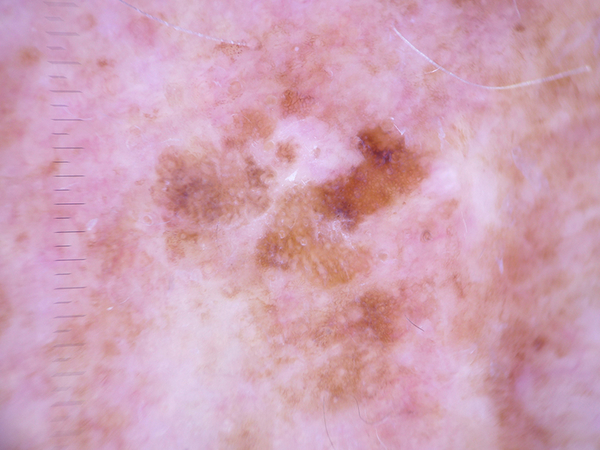

In [9]:
print(metadata.iloc[0])
image

#### Creating Custom Data Loader

In [10]:
import torch 
from torch.utils.data import Dataset

In [11]:
class CustomDataLoader(Dataset): 
    def __init__(self, metadata, path, transpose = None, target_transpose = None): 
        self.img_data = metadata
        self.img_path = path 
        self.transpose = transpose 
        self.target_transpose = target_transpose

    def __len__(self): 
        return len(self.img_data)

    def __getitem__(self, idx): 
        self.img_id = self.img_data.iloc[idx]['image_id']
        img_path = f'{self.img_path}_1/{self.img_id}.jpg' if os.path.exists(f'{self.img_path}_1/{self.img_id}.jpg')  else f'{self.img_path}_2/{self.img_id}.jpg'
        image = Image.open(img_path)
        label = self.img_data.iloc[idx]['dx']
        if self.transpose: 
            image = self.transpose(image)
        if self.target_transpose: 
            label = self.target_transpose(label)

        return image, label

In [12]:
image_loader = CustomDataLoader(metadata, '../data/raw/HAM10000_images_part')

In [13]:
image_1, label_1 = image_loader[0]

bkl


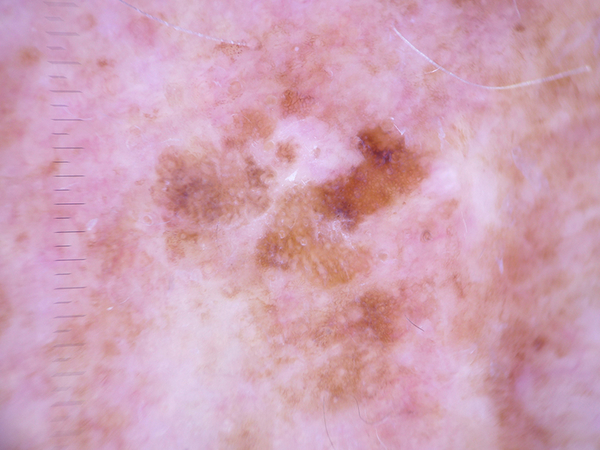

In [14]:
print(label_1)
image_1

#### Let's Do Some Visualization Of The MetaData And Get Insights

In [15]:
dx = metadata['dx'].value_counts()
dx

dx
nv       6705
mel      1113
bkl      1099
bcc       514
akiec     327
vasc      142
df        115
Name: count, dtype: int64

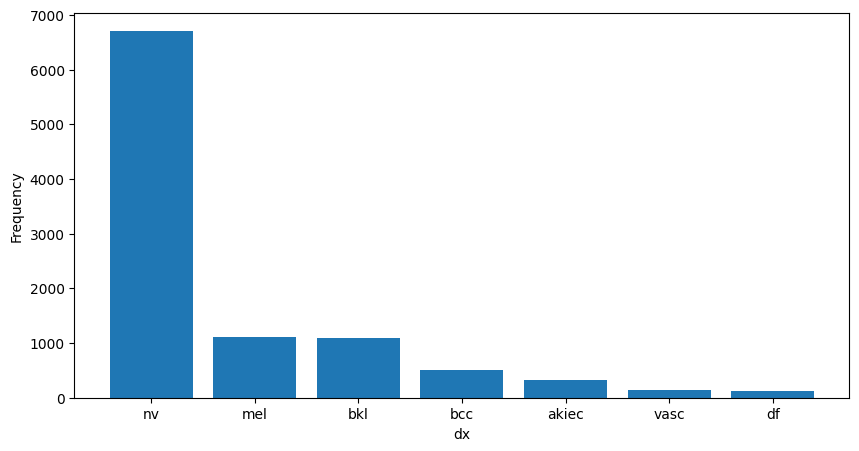

In [16]:
plt.figure(figsize=(10,5))

plt.bar(dx.keys(), dx)
plt.xlabel("dx")
plt.ylabel("Frequency")
plt.show()

In [17]:
dx.keys()

Index(['nv', 'mel', 'bkl', 'bcc', 'akiec', 'vasc', 'df'], dtype='object', name='dx')

#### We Can See That Majority Of The Data Is Melanocytic Nevi (nv) 
We Will Now See The Percentages Of The Data Distribution

In [18]:
round(dx / len(metadata), 3)

dx
nv       0.669
mel      0.111
bkl      0.110
bcc      0.051
akiec    0.033
vasc     0.014
df       0.011
Name: count, dtype: float64

* 67% Of The Data IS Given To NV 

* There is A High Imbalace Of The Class Weights Of The Targets, We Will See How To Solve That Later

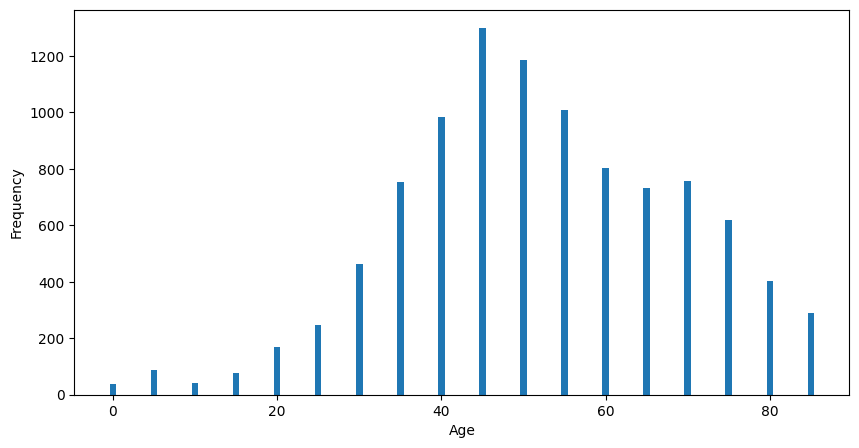

In [19]:
plt.figure(figsize=(10,5))

plt.bar(metadata['age'].value_counts().keys(), metadata['age'].value_counts())
plt.xlabel("Age")
plt.ylabel("Frequency")
plt.show()

In [20]:
round(metadata['age'].value_counts() / len(metadata), 3)

age
45.0    0.130
50.0    0.119
55.0    0.101
40.0    0.098
60.0    0.080
70.0    0.075
35.0    0.075
65.0    0.073
75.0    0.062
30.0    0.046
80.0    0.040
85.0    0.029
25.0    0.025
20.0    0.017
5.0     0.009
15.0    0.008
10.0    0.004
0.0     0.004
Name: count, dtype: float64

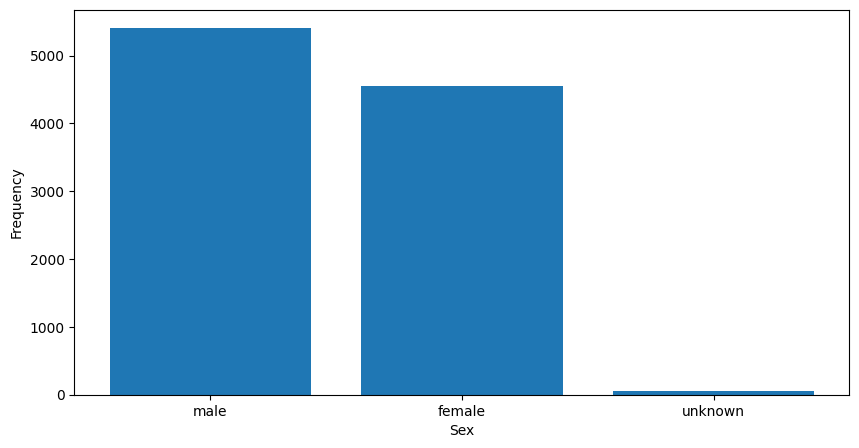

In [21]:
plt.figure(figsize=(10,5))

plt.bar(metadata['sex'].value_counts().keys(), metadata['sex'].value_counts())
plt.xlabel("Sex")
plt.ylabel("Frequency")
plt.show()

In [22]:
round(metadata['sex'].value_counts() / len(metadata), 3)

sex
male       0.540
female     0.455
unknown    0.006
Name: count, dtype: float64

* We Can Observe That The Disease Is More Likely To Be Gotten For Middle Age(30-50) and Old Age Than Teens Or Children
* The Male And Female Differnce Is Not Noticible But We Can Give Extra Weights For Female To Get The Model To Be Unbaised

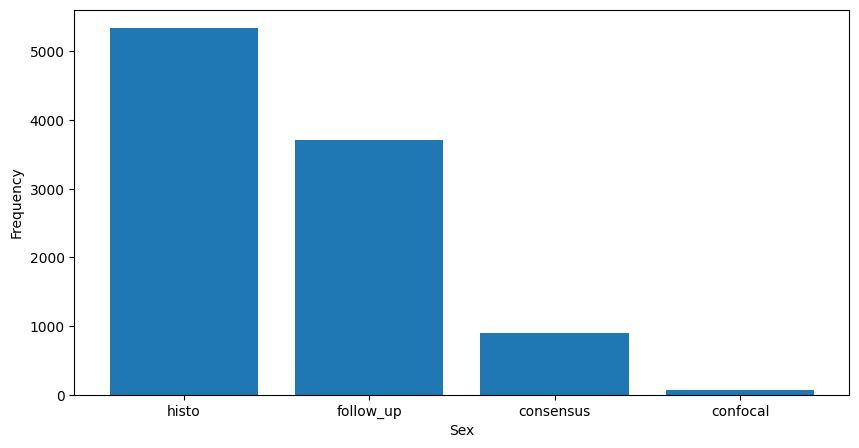

In [23]:
plt.figure(figsize=(10,5))

plt.bar(metadata['dx_type'].value_counts().keys(), metadata['dx_type'].value_counts())
plt.xlabel("Sex")
plt.ylabel("Frequency")
plt.show()

* Most Of Were Caught In Histopathology (histo), And Most Went For Follow Up By The Doctors
* Expert Consensus (consensus) For A Few Percentage
* Confirmation by In-vivo Confocal Microscopy (confocal)

To Get The Exact Percentages

In [24]:
round(metadata['dx_type'].value_counts() / len(metadata), 3)

dx_type
histo        0.533
follow_up    0.370
consensus    0.090
confocal     0.007
Name: count, dtype: float64

### Splitting Data For Train-Test-Val And Data Loading 

In [25]:
from sklearn.model_selection import train_test_split
from torch.utils.data import DataLoader
import torchvision.transforms.v2 as T

In [26]:
dx.keys()

Index(['nv', 'mel', 'bkl', 'bcc', 'akiec', 'vasc', 'df'], dtype='object', name='dx')

In [27]:
label = {'nv' : 0, 'mel' : 1, 'bkl' : 2, 'bcc' : 3, 'akiec' : 4, 'vasc' : 5, 'df' : 6} 
# Mapping The Labels According To Value Counts For Training 

In [28]:
metadata['dx'] = metadata['dx'].map(label)

X = metadata.drop('dx', axis=1)
y = metadata['dx']

In [29]:
train_data , sample_data = train_test_split(metadata, stratify=metadata['dx'], random_state=42,test_size=0.3)
test_data, val_data = train_test_split(sample_data, random_state=42, test_size=0.5, stratify=sample_data['dx'])

#### Data Transformation Data Augumentation So That It Does Not Overfit And So That Model Genelarizes Better And Not Predict Based On Just Color

In [30]:
train_transform = T.Compose([
    T.RandomRotation(20), 
    T.RandomHorizontalFlip(p=0.4), 
    T.ColorJitter(brightness=0.2, contrast=0.2),
    T.Resize((224,224)), 
    T.ToTensor(),
    T.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225])
])

val_transform = T.Compose([   # No Need To Transform The Test And Validation Set Since It's Not Used For Training
    T.Resize((224,224)), 
    T.ToTensor(),
    T.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225])
])

C:\Users\Tarun V\Desktop\DS\env\Lib\site-packages\torchvision\transforms\v2\_deprecated.py:42: UserWarning: The transform `ToTensor()` is deprecated and will be removed in a future release. Instead, please use `v2.Compose([v2.ToImage(), v2.ToDtype(torch.float32, scale=True)])`.Output is equivalent up to float precision.
  warnings.warn(


In [31]:
train_dl = CustomDataLoader(train_data, '../data/raw/HAM10000_images_part', transpose=train_transform)
test_dl = CustomDataLoader(test_data, '../data/raw/HAM10000_images_part',transpose= val_transform) 
val_dl = CustomDataLoader(val_data, '../data/raw/HAM10000_images_part', transpose=val_transform)

In [32]:
train_loader = DataLoader(train_dl, batch_size=32, pin_memory=True)
test_loader = DataLoader(test_dl, batch_size=32) 
val_loader = DataLoader(val_dl, batch_size=32)

#### Now For Model Creation

In [33]:
import torchvision
import torchmetrics
import torch.nn as nn 

* We Are Taking ResNet18 To Use The Pretrained Weights
* We Can Use This Model To Identify All The Problems Which Could Be Useful When We Use A Better Model

In [34]:
model = torchvision.models.resnet18

In [35]:
weights = torchvision.models.ResNet18_Weights.IMAGENET1K_V1

In [36]:
device = 'cuda'

In [37]:
model = model(weights=weights).to(device)

In [38]:
def evaluate_tm(model,valid_loader,metrics): 
    model.eval()
    for X_batch, y_batch in valid_loader: 
        X_batch, y_batch = X_batch.to(device), y_batch.to(device)
        y_pred = model(X_batch)
        metrics(y_pred, y_batch)

    return metrics.compute()


def train(model, train_loader, metrics, loss_fn, optimizer, valid_loader, n_epochs): 
    result = {"train_loss": [], "train_metric": [], "Validation_metric" : []}
    for epoch in range(n_epochs): 
        model.train()
        metrics.reset()
        total_loss = 0
        for X_batch, y_batch in train_loader: 
            X_batch, y_batch = X_batch.to(device), y_batch.to(device)
            y_pred = model(X_batch)
            loss = loss_fn(y_pred, y_batch)
            metrics(y_pred, y_batch)
            total_loss += loss 
            loss.backward()
            optimizer.step()
            optimizer.zero_grad()

        result["train_loss"].append(total_loss / len(train_loader))
        result["train_metric"].append(metrics.compute().item())
        result["Validation_metric"].append(evaluate_tm(model, valid_loader, metrics).item())

        print(f"Epoch {epoch + 1}/{n_epochs} :  "
              f"train loss: {result['train_loss'][-1]:.4f}, "
              f"train metric: {result['train_metric'][-1]:.4f}, "
              f"valid metric: {result['Validation_metric'][-1]:.4f}")
    return result

In [39]:
[names for names,child in model.named_children()] # To Know What Are The Layers Used In Resnet18, Better To Know For Debugging

['conv1',
 'bn1',
 'relu',
 'maxpool',
 'layer1',
 'layer2',
 'layer3',
 'layer4',
 'avgpool',
 'fc']

In [40]:
model.fc

Linear(in_features=512, out_features=1000, bias=True)

In [41]:
model.fc = nn.Linear(in_features=512, out_features=7).to(device) # We Are Changing The No. Of Outputs SSince We Only Have 7 Classes, So We Replace 1000 With 7

### Training The Model

#### UnFreezing Only The Classification Head And Seeing The Results, Note That We havent Started Any Training Yet

In [42]:
for param in model.parameters(): 
    param.requires_grad = False 

for param in model.fc.parameters(): 
    param.requires_grad = True    

In [43]:
n_epochs = 5
xentropy = nn.CrossEntropyLoss().to(device)
accuracy = torchmetrics.Accuracy(task='multiclass', num_classes=7).to(device)
optimizer = torch.optim.AdamW(model.fc.parameters(), lr=0.003)
history = train(model, train_loader, accuracy, xentropy, optimizer, val_loader, n_epochs)

Epoch 1/5 :  train loss: 0.8971, train metric: 0.7049, valid metric: 0.6994
Epoch 2/5 :  train loss: 0.7803, train metric: 0.7231, valid metric: 0.7194
Epoch 3/5 :  train loss: 0.7492, train metric: 0.7421, valid metric: 0.7337
Epoch 4/5 :  train loss: 0.7396, train metric: 0.7389, valid metric: 0.7312
Epoch 5/5 :  train loss: 0.7138, train metric: 0.7476, valid metric: 0.7379


* OHH WoW The Accuracy is almost ~74% on Both Training And Validation Data
* It May Look Promising to see 74% accuracy on just 5 epochs, But it is not as good as u might think, that's why accuracy is a lie in medical fields.
* Let's See why accuracy is not telling the entire plot,
* As We know 67% and 11% of the data is made up of 'nv' and 'mel' total of 78%, if a model is not confident in its prediction it may choose nv which consists 67% of the dataset and 67% of the time it will be correct ,this is no diffferent than random guessing knowing that majority of the dataset is 'nv', and the model shows high bias towards 'nv'.
* And because of this fact the model wont go above ~78% accuracy(Checked While Running Many Epochs) and in medical field wrongly classifying diseases because they are most common is very dangerous
* To get better understanding for it we need to use precision, recall and confusion matrix to get to know what's acctuall going on
* To Balance this imbalance dataset we can give class weights according to there inverse and we can also use sklearn class_weights function

In [44]:
from sklearn.metrics import precision_score, recall_score, confusion_matrix, ConfusionMatrixDisplay,classification_report

In [45]:
def evaluate_tm1(model,valid_loader): 
    with torch.no_grad():
        model.eval()
        y_predicted = []
        y_label = []
        for X_batch, y_batch in valid_loader: 
            X_batch, y_batch = X_batch.to(device), y_batch
            y_pred = model(X_batch)
            y_pred = y_pred.argmax(axis=1).cpu()
            y_predicted.append(y_pred.numpy())
            y_label.append(y_batch.numpy())

    return y_predicted, y_label

In [46]:
y_pred, y_true = evaluate_tm1(model, val_loader)

In [47]:
y_pred_2 = [item for sublist in y_pred for item in sublist]
y_true_2 = [item for sublist in y_true for item in sublist]

In [48]:
print(classification_report(y_true_2, y_pred_2,target_names=['nv','mel' ,'bkl','bcc','akiec','vasc','df']))

              precision    recall  f1-score   support

          nv       0.93      0.77      0.84      1006
         mel       0.41      0.57      0.47       167
         bkl       0.35      0.79      0.49       165
         bcc       0.71      0.19      0.31        77
       akiec       0.57      0.08      0.14        49
        vasc       0.56      0.82      0.67        22
          df       0.50      0.18      0.26        17

    accuracy                           0.69      1503
   macro avg       0.58      0.49      0.45      1503
weighted avg       0.78      0.69      0.70      1503



In [49]:
class_weights = (1/dx) * 1000
class_weights = torch.Tensor(class_weights)

C:\Users\Tarun V\AppData\Local\Temp\ipykernel_16012\2967788934.py:2: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`
  class_weights = torch.Tensor(class_weights)


In [50]:
n_epochs = 5
xentropy = nn.CrossEntropyLoss(weight=class_weights).to(device)
accuracy = torchmetrics.Accuracy(task='multiclass', num_classes=7).to(device)
optimizer = torch.optim.AdamW(model.fc.parameters(), lr=0.003)
history = train(model, train_loader, accuracy, xentropy, optimizer, val_loader, n_epochs)

Epoch 1/5 :  train loss: 1.2100, train metric: 0.6083, valid metric: 0.6037
Epoch 2/5 :  train loss: 1.1185, train metric: 0.6271, valid metric: 0.6126
Epoch 3/5 :  train loss: 1.1131, train metric: 0.6332, valid metric: 0.6194
Epoch 4/5 :  train loss: 1.1164, train metric: 0.6322, valid metric: 0.6168
Epoch 5/5 :  train loss: 1.0844, train metric: 0.6301, valid metric: 0.6166


* We can see that the model is actually trying to predict the actual label rather than just guessing 'nv'
* as we are just training on the last layer the accuracy will be low , so let's unfreeze a few layers and check

In [51]:
for param in model.parameters(): 
    param.requires_grad = False 

for param in model.layer4.parameters():     # Unfreezing last 3 layers to train and adjust to the medical images
    param.requires_grad = True 

for param in model.layer3.parameters(): 
    param.requires_grad = True 

for param in model.fc.parameters(): 
    param.requires_grad = True 

In [52]:
n_epochs = 5
xentropy = nn.CrossEntropyLoss(weight=class_weights).to(device)
accuracy = torchmetrics.Accuracy(task='multiclass', num_classes=7).to(device)
parameters = [p for p in model.parameters() if p.requires_grad]
optimizer = torch.optim.AdamW(parameters, lr=0.001)
history = train(model, train_loader, accuracy, xentropy, optimizer, val_loader, n_epochs)

Epoch 1/5 :  train loss: 1.7361, train metric: 0.5364, valid metric: 0.5580
Epoch 2/5 :  train loss: 1.0553, train metric: 0.6178, valid metric: 0.6214
Epoch 3/5 :  train loss: 0.9000, train metric: 0.6512, valid metric: 0.6505
Epoch 4/5 :  train loss: 0.8195, train metric: 0.6729, valid metric: 0.6655
Epoch 5/5 :  train loss: 0.7768, train metric: 0.6832, valid metric: 0.6838


In [53]:
for param in model.parameters(): 
    param.requires_grad = False 

for param in model.layer4.parameters():  ## Unfreezing Only Last 2 layers to train before prediction
    param.requires_grad = True 

for param in model.fc.parameters(): 
    param.requires_grad = True 

In [54]:
from sklearn.utils.class_weight import compute_class_weight

In [55]:
# Computing class_weights using sklearn
class_weights = compute_class_weight('balanced', classes=np.unique(metadata['dx']), y=metadata['dx']) 

In [56]:
class_weights = torch.Tensor(class_weights)
class_weights # Remember to convert it into tensor to be compatible with training

tensor([ 0.2134,  1.2855,  1.3018,  2.7835,  4.3753, 10.0755, 12.4410])

In [57]:
n_epochs = 5
xentropy = nn.CrossEntropyLoss(weight=class_weights).to(device)
accuracy = torchmetrics.Accuracy(task='multiclass', num_classes=7).to(device)
parameters = [p for p in model.parameters() if p.requires_grad]
optimizer = torch.optim.AdamW(parameters, lr=0.0005)
history = train(model, train_loader, accuracy, xentropy, optimizer, val_loader, n_epochs)

Epoch 1/5 :  train loss: 0.6360, train metric: 0.7165, valid metric: 0.7135
Epoch 2/5 :  train loss: 0.5294, train metric: 0.7482, valid metric: 0.7466
Epoch 3/5 :  train loss: 0.4947, train metric: 0.7583, valid metric: 0.7538
Epoch 4/5 :  train loss: 0.4741, train metric: 0.7633, valid metric: 0.7642
Epoch 5/5 :  train loss: 0.4044, train metric: 0.7802, valid metric: 0.7788


* The loss from when class was imbalanced and with accuracy 74% was 0.7169, now with 75% accuracy but the loss is 0.40

#### Confusion Matrix

In [58]:
y_pred, y_true = evaluate_tm1(model, val_loader)

In [59]:
y_pred_2 = [item for sublist in y_pred for item in sublist]
y_true_2 = [item for sublist in y_true for item in sublist]

In [60]:
print(classification_report(y_true_2, y_pred_2,target_names=['nv','mel' ,'bkl','bcc','akiec','vasc','df']))

              precision    recall  f1-score   support

          nv       0.94      0.82      0.88      1006
         mel       0.43      0.66      0.52       167
         bkl       0.64      0.61      0.63       165
         bcc       0.69      0.74      0.71        77
       akiec       0.52      0.65      0.58        49
        vasc       0.46      0.95      0.62        22
          df       0.60      0.71      0.65        17

    accuracy                           0.77      1503
   macro avg       0.61      0.74      0.66      1503
weighted avg       0.81      0.77      0.79      1503



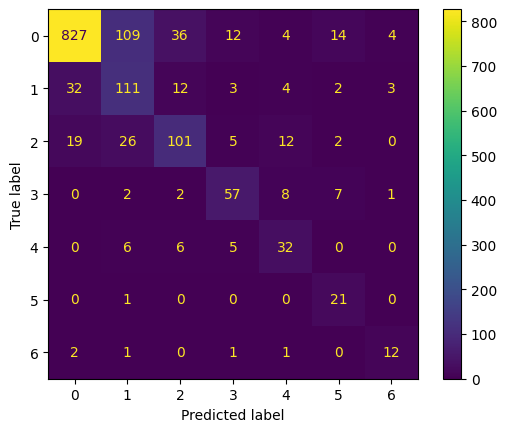

In [61]:
ConfusionMatrixDisplay(confusion_matrix(y_true_2, y_pred_2)).plot();

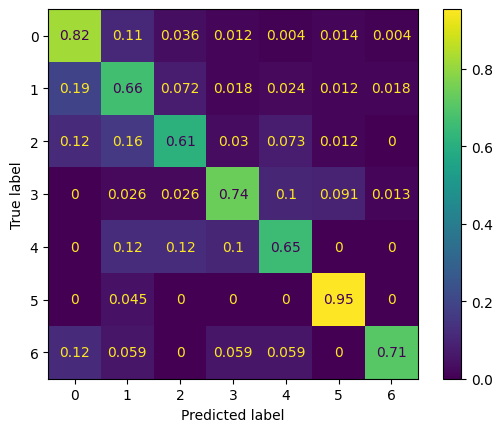

In [62]:
ConfusionMatrixDisplay(confusion_matrix(y_true_2, y_pred_2, normalize='true')).plot();

* We can observe that recall of label 0,3,5 are high
* As this project is for understanding real life medical images and interpreting them we have to prioritze on which diseases get's high recall rate, we can do that by giving it more weight or adjusting the threshold, we will see this later
* The One's to give priority are :
* Melanoma (mel) - MOST DANGEROUS ,label 1
* Basal Cell Carcinoma (bcc), label 3
* Although bcc is not as dangerous as melanoma, the recall rate is high right now
* so Now lets focus on melanoma, the most dangerous one and needs to caught as early as possible

In [63]:
import torch.nn.functional as F

In [64]:
model.eval()
y_pred1 = []
y_true1 = []

with torch.no_grad(): 
    for X_val, y_val in val_loader: 
        X_val = X_val.to(device)
        y_pred = model(X_val)
        y_pred = y_pred.argmax(dim=1).to('cpu')
        y_pred1.append(y_pred.numpy())
        y_true1.append(y_val.numpy())

y_pred_2 = [item for sublist in y_pred1 for item in sublist]
y_true_2 = [item for sublist in y_true1 for item in sublist]

In [65]:
print(classification_report(y_true_2, y_pred_2,target_names=['nv','mel' ,'bkl','bcc','akiec','vasc','df']))

              precision    recall  f1-score   support

          nv       0.94      0.82      0.88      1006
         mel       0.43      0.66      0.52       167
         bkl       0.64      0.61      0.63       165
         bcc       0.69      0.74      0.71        77
       akiec       0.52      0.65      0.58        49
        vasc       0.46      0.95      0.62        22
          df       0.60      0.71      0.65        17

    accuracy                           0.77      1503
   macro avg       0.61      0.74      0.66      1503
weighted avg       0.81      0.77      0.79      1503



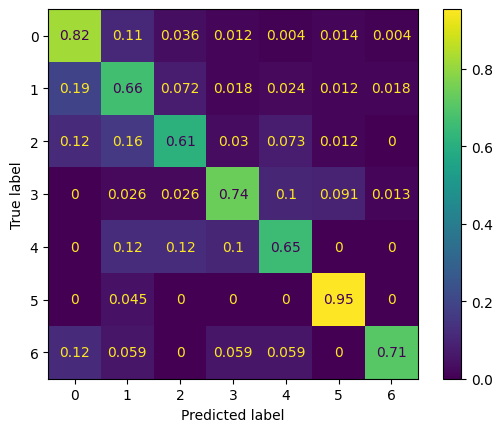

In [66]:
ConfusionMatrixDisplay(confusion_matrix(y_true_2, y_pred_2, normalize='true')).plot();

* in here we can also observe that many of the false predictions from label 0 as reduced for melanoma
* Next we will assign weights to 'mel' to penalize more to the model when it makes mistake on the melanoma , should have done this way before 😅, but in here we will just use brute force and guess a high weight

In [67]:
class_weights

tensor([ 0.2134,  1.2855,  1.3018,  2.7835,  4.3753, 10.0755, 12.4410])

In [68]:
class_weights[1] = torch.tensor(3.0)  # Brute Forcing Or Randomly Chossing High Weights
class_weights[5] = torch.tensor(5.0)
class_weights[6] = torch.tensor(5.0)

In [69]:
n_epochs = 5
xentropy = nn.CrossEntropyLoss(weight=class_weights).to(device)
accuracy = torchmetrics.Accuracy(task='multiclass', num_classes=7).to(device)
parameters = [p for p in model.parameters() if p.requires_grad]
optimizer = torch.optim.AdamW(parameters, lr=0.0005)
history = train(model, train_loader, accuracy, xentropy, optimizer, val_loader, n_epochs)

Epoch 1/5 :  train loss: 0.4336, train metric: 0.7491, valid metric: 0.7472
Epoch 2/5 :  train loss: 0.4101, train metric: 0.7625, valid metric: 0.7615
Epoch 3/5 :  train loss: 0.3715, train metric: 0.7749, valid metric: 0.7707
Epoch 4/5 :  train loss: 0.3539, train metric: 0.7805, valid metric: 0.7742
Epoch 5/5 :  train loss: 0.3540, train metric: 0.7894, valid metric: 0.7835


#### Tuning Threshold To Get Desired Recall For Melanoma 

In [70]:
# Just focus on melanoma detection (binary problem)
def analyze_melanoma_detection(y_true, y_pred_probs):
    """
    Treat melanoma detection as binary: melanoma vs everything else
    """
    from sklearn.metrics import roc_curve, precision_recall_curve, auc
    y_true = pd.DataFrame(y_true)
    # Binary labels: 1 if melanoma, 0 otherwise
    y_true_binary = (y_true == 1).astype(int)  # Assuming melanoma is class 1
    melanoma_probs = y_pred_probs[:, 1]  # Probability of melanoma
    
    fpr, tpr, roc_thresholds = roc_curve(y_true_binary, melanoma_probs)
    roc_auc = auc(fpr, tpr)
    
    precision, recall, pr_thresholds = precision_recall_curve(y_true_binary, melanoma_probs)
    
    target_recall = 0.85
    idx = np.argmin(np.abs(recall - target_recall)) # argmin Gives The Index Position Of The Desired Recall Which Can Be Used In Thresholds
    optimal_threshold = pr_thresholds[idx] if idx < len(pr_thresholds) else 0.5
    
    print(f"Threshold for {target_recall*100}% recall: {optimal_threshold:.3f}")
    print(f"Precision at this point: {precision[idx]:.3f}")
    
    return optimal_threshold, precision, recall, pr_thresholds

In [71]:
model.eval()
y_pred_probs = []
y_true_labels = []

with torch.no_grad(): 
    for X_val, y_val in val_loader: 
        X_val = X_val.to(device)
        y_pred = model(X_val)
        y_pred = F.softmax(y_pred, dim=1).to('cpu')
        
        y_pred_probs.append(y_pred.numpy())
        y_true_labels.append(y_val.numpy())

y_pred_probs = [item for sublist in y_pred_probs for item in sublist.tolist()]
y_true_labels = [item for sublist in y_true_labels for item in sublist]

optimal_thresh, precision, recall, pr_thresholds = analyze_melanoma_detection(y_true_labels, np.round(np.array(y_pred_probs),3))
print(f"Use threshold: {optimal_thresh:.3f} instead of your current 0.3")

Threshold for 85.0% recall: 0.255
Precision at this point: 0.338
Use threshold: 0.255 instead of your current 0.3


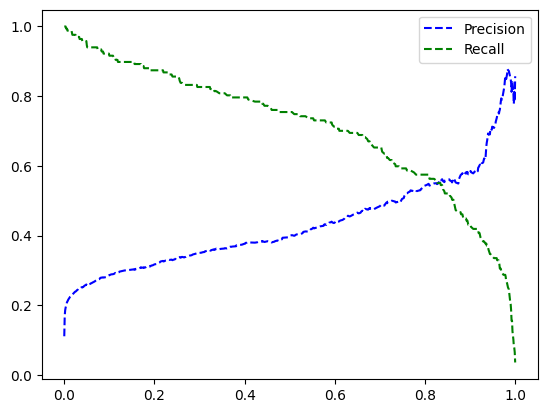

In [72]:
plt.plot(pr_thresholds, precision[:-1], 'b--', label='Precision')
plt.plot(pr_thresholds, recall[:-1], 'g--', label='Recall')
plt.legend();

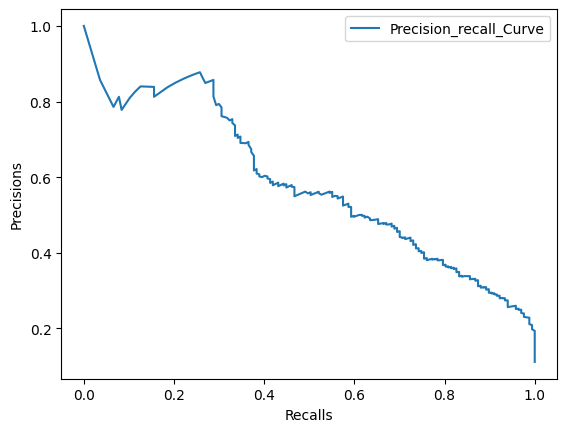

In [73]:
plt.plot(recall,precision, label='Precision_recall_Curve')
plt.xlabel("Recalls")
plt.ylabel("Precisions")
plt.legend();

In [74]:
model.eval()
y_pred1 = []
y_true1 = []

with torch.no_grad(): 
    for X_val, y_val in val_loader: 
        X_val = X_val.to(device)
        y_pred = model(X_val)
        y_pred = y_pred.argmax(dim=1).to('cpu')
        y_pred1.append(y_pred.numpy())
        y_true1.append(y_val.numpy())

y_pred_2 = [item for sublist in y_pred1 for item in sublist]
y_true_2 = [item for sublist in y_true1 for item in sublist]

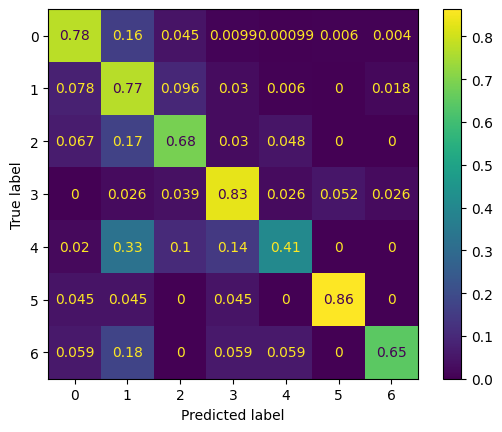

In [75]:
ConfusionMatrixDisplay(confusion_matrix(y_true_2, y_pred_2, normalize='true')).plot();

In [76]:
y_pred = []

for i in range(len(y_pred_2)): 
    if(y_pred_probs[i][1] > 0.241 ): 
        y_pred.append(1)
    else: 
        y_pred.append(int(np.argmax(y_pred_probs[i])))

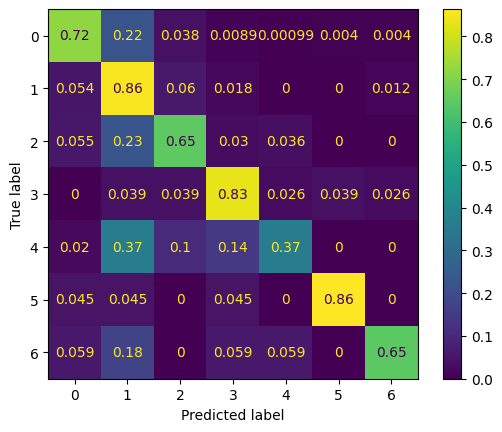

In [77]:
ConfusionMatrixDisplay(confusion_matrix(y_true_2, y_pred, normalize='true')).plot();

In [78]:
print(classification_report(y_true_2, y_pred,target_names=['nv','mel' ,'bkl','bcc','akiec','vasc','df']))

              precision    recall  f1-score   support

          nv       0.97      0.72      0.83      1006
         mel       0.33      0.86      0.48       167
         bkl       0.66      0.65      0.65       165
         bcc       0.71      0.83      0.77        77
       akiec       0.64      0.37      0.47        49
        vasc       0.73      0.86      0.79        22
          df       0.58      0.65      0.61        17

    accuracy                           0.72      1503
   macro avg       0.66      0.70      0.66      1503
weighted avg       0.83      0.72      0.75      1503



* We Increased the recall for melanoma and bcc which were the dangerous ones , although the precision is dropped to 0.33 for melanoma and bbc as 0.71 as precision
* Let's Analize the images and find out the reason for the low the precision

#### Visualizing The Images Which Was Wrongly Predicted By The Model And Getting Insights

In [79]:
vis_images = []
for i in range(len(y_pred)): 
    if (y_pred[i] == 0 and y_true_2[i] == 1): 
        idx = i 
        y = int(val_loader.dataset.img_data.index[idx])
        vis_image, vis_lable = image_loader[y]
        vis_images.append(vis_image)

In [80]:
vis_images1 = []
for i in range(len(y_pred)): 
    if (y_true_2[i] == 1).any(): # Melanoma
        idx = i 
        y = int(val_loader.dataset.img_data.index[idx])
        vis_image1, vis_lables1 = image_loader[y]
        vis_images1.append(vis_image1)

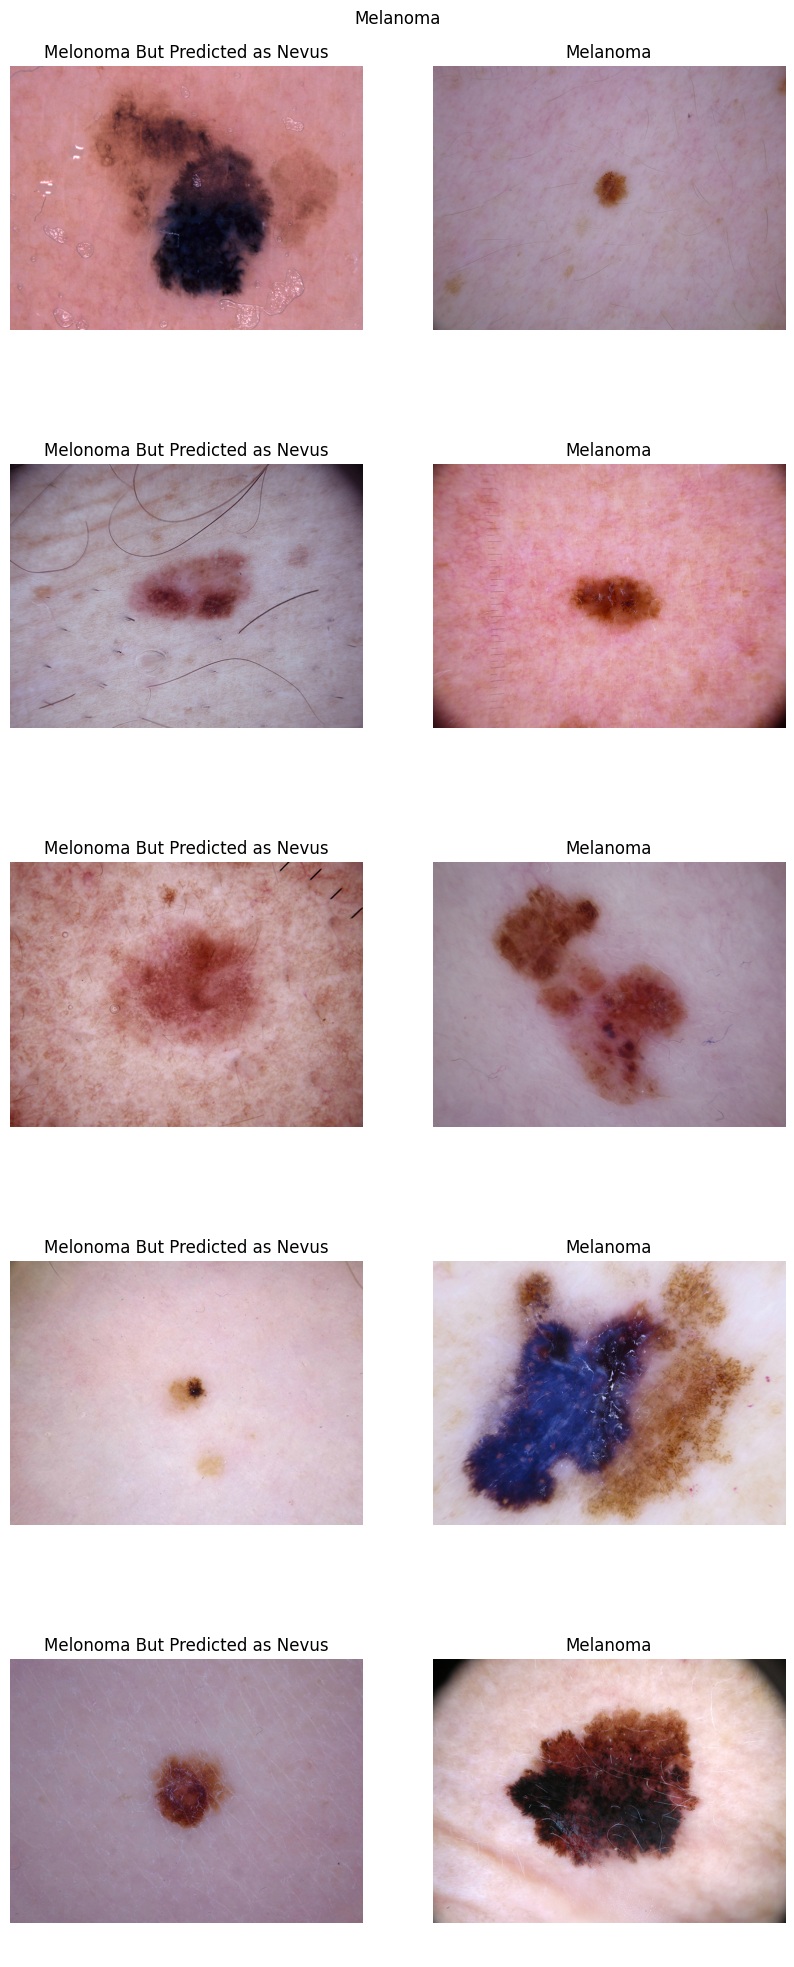

In [81]:
plt.figure(figsize=(10,5*5))
plt.title("Melanoma")
plt.axis('off')
for i in range(5): 
    plt.subplot(5,2,2*i + 1)
    plt.imshow(vis_images[i])
    plt.title("Melonoma But Predicted as Nevus")
    plt.axis('off')

    plt.subplot(5,2,2*i + 2)
    plt.title("Melanoma")
    plt.imshow(vis_images1[i])
    plt.axis('off')

* From the images we can identify that the prediction was due to the fact that melanoma was in the earlier stages which would look as same as nevus
* We can also observe that later stage of melanoma are dark and so the model probably learned it and nevus lookk lighter so the early stage melanoma were classified as nevus and thus reduction in precision

In [82]:
model.eval()

activation = {}

def get_activation(name): 
    def hook(model, input, output):  
        activation[name] = output 
    return hook

In [83]:
gradients =  {}

def get_gradient(name):
    def hook(grad):
        gradients[name] = grad
    return hook

In [84]:
model.layer4.register_forward_hook(get_activation('layer4'))

In [85]:
img = train_transform(image)
img_tensor = img.unsqueeze(dim=0)
img_tensor = img_tensor.to(device).requires_grad_()

In [86]:
img_tensor.shape

torch.Size([1, 3, 224, 224])

In [87]:
output = model(img_tensor)

In [88]:
activation['layer4'].register_hook(get_gradient('layer4'))

In [89]:
target_class = output.argmax(dim=1).item()
target_class

2

In [90]:
score = output[0, target_class]
score

tensor(6.6066, device='cuda:0', grad_fn=<SelectBackward0>)

In [91]:
model.zero_grad() 
score.backward()

In [92]:
activation['layer4'].detach().shape

torch.Size([1, 512, 7, 7])

In [93]:
activation = activation['layer4'].detach()  # (1, 512, 7, 7)
gradient = gradients['layer4'].detach()      # (1, 512, 7, 7)

* Remember how you did score.backward() to compute gradients? After that, the activations and gradients are still connected to the computation graph — PyTorch is still tracking everything for potential further backpropagation.
* detach() cuts that connection. You're done with backprop at that point, you just want the raw numbers to build your heatmap. So you detach them to say "I don't need the graph anymore, just give me the values."
* Without detach, PyTorch would waste memory keeping track of operations you don't need anymore.

In [94]:
weights = gradient.mean(dim=(2, 3)) # (1, 512) 
weights.shape

torch.Size([1, 512])

In [95]:
# Weighted sum of activation maps
cam = (weights.unsqueeze(-1).unsqueeze(-1) * activation).sum(dim=1)  # (1, 7, 7)
cam = torch.relu(cam)  # only care about positive influence

In [96]:
cam

tensor([[[0.0000, 0.0070, 0.0239, 0.0389, 0.0415, 0.0181, 0.0032],
         [0.0000, 0.0310, 0.1227, 0.2175, 0.1917, 0.1075, 0.0327],
         [0.0000, 0.0785, 0.2831, 0.4572, 0.4306, 0.2555, 0.0762],
         [0.0000, 0.1020, 0.3272, 0.5678, 0.5529, 0.3631, 0.1073],
         [0.0000, 0.0556, 0.2328, 0.4278, 0.4057, 0.2589, 0.0824],
         [0.0000, 0.0174, 0.1114, 0.2090, 0.1803, 0.1208, 0.0502],
         [0.0000, 0.0000, 0.0188, 0.0386, 0.0398, 0.0367, 0.0273]]],
       device='cuda:0')

In [97]:
activation.shape

torch.Size([1, 512, 7, 7])

In [98]:
# 5. Overlay on original image
import cv2
import numpy as np

cam_np = cam[0].cpu().numpy()
cam_np = cv2.resize(cam_np, (224, 224))
cam_np = (cam_np - cam_np.min()) / (cam_np.max() - cam_np.min())  # normalize 0-1
heatmap = cv2.applyColorMap((cam_np * 255).astype(np.uint8), cv2.COLORMAP_JET)

# Convert original image back from tensor to numpy
original = img_tensor[0].permute(1, 2, 0).cpu().detach().numpy()
original = ((original * np.array([0.229, 0.224, 0.225])) + np.array([0.485, 0.456, 0.406])) * 255
original = original.astype(np.uint8)

overlay = cv2.addWeighted(original, 0.6, heatmap, 0.4, 0)

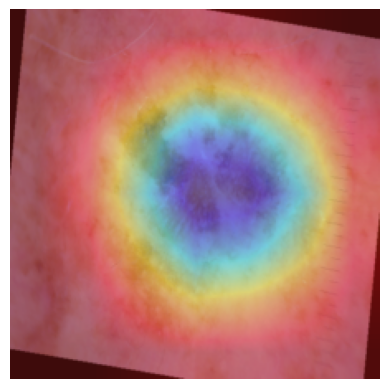

In [99]:
plt.imshow(overlay)
plt.axis('off');

In [100]:
img.shape

torch.Size([3, 224, 224])

In [101]:
def get_activation(name): 
    def hook(model, input, output):  
        activation[name] = output 
    return hook

def get_gradient(name):
    def hook(grad):
        gradient[name] = grad
    return hook

activation = {}
gradient = {}

In [102]:
def grad_cam(model, imgs): 
    model.eval()
    for imgs, labels in imgs: 
        imgs = imgs.to(device)
        break
    model.layer4.register_forward_hook(get_activation('layer4'))
    imgs = imgs.requires_grad_()
    output = model(imgs) 
    activation['layer4'].register_hook(get_gradient('layer4'))
    pred = output.argmax(dim=1)
    score = output.gather(1, pred.unsqueeze(1)).squeeze()
    
    model.zero_grad()
    score.sum().backward()

    activations = activation['layer4'].detach()
    gradients = gradient['layer4'].detach()

    weights = gradients.mean(dim=(2,3))
    weights = weights.to(device)    

    cam = (weights.unsqueeze(-1).unsqueeze(-1) * activations).sum(dim=1)
    cam = torch.relu(cam)

    for i in range(cam.shape[0]):
        if(i<5):
            cam_np = cam[i].cpu().numpy()
            cam_np = cv2.resize(cam_np, (224, 224))
            cam_np = (cam_np - cam_np.min()) / (cam_np.max() - cam_np.min())  # normalize 0-1
            heatmap = cv2.applyColorMap((cam_np * 255).astype(np.uint8), cv2.COLORMAP_JET)
            
            # Convert original image back from tensor to numpy
            original = imgs[i].permute(1, 2, 0).cpu().detach().numpy()
            original = ((original * np.array([0.229, 0.224, 0.225])) + np.array([0.485, 0.456, 0.406])) * 255
            original = original.astype(np.uint8)
            
            overlay = cv2.addWeighted(original, 0.6, heatmap, 0.4, 0)
            plt.figure()
            plt.imshow(overlay)
            plt.axis('off');
        else:
            break

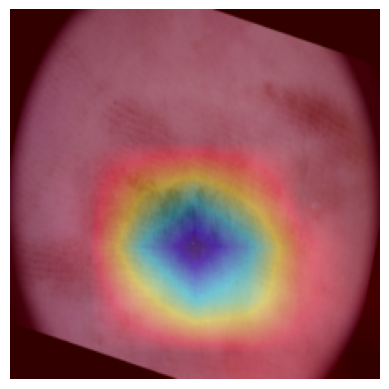

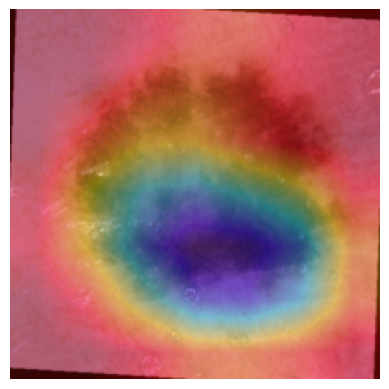

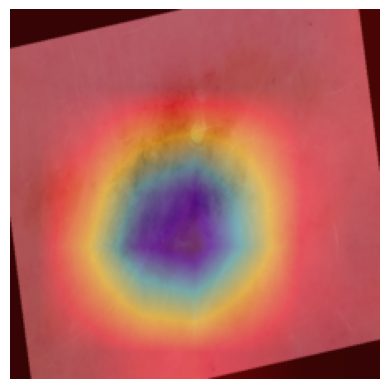

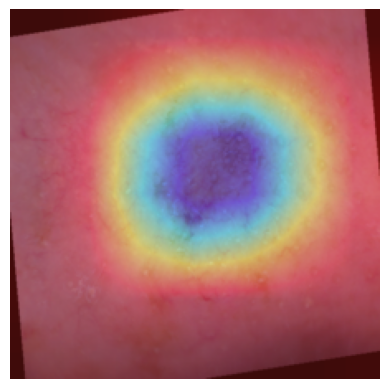

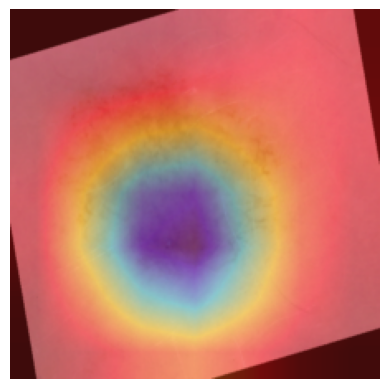

In [103]:
grad_cam(model, train_loader)

In [104]:
def grad_cam(model, imgs): 
    model.eval()
    imgs = imgs.to(device)
    
    model.layer4.register_forward_hook(get_activation('layer4'))
    imgs = imgs.unsqueeze(dim=0).requires_grad_()
    output = model(imgs) 
    activation['layer4'].register_hook(get_gradient('layer4'))
    pred = output.argmax(dim=1)
    score = output[0,pred]
    
    model.zero_grad()
    score.backward()

    activations = activation['layer4'].detach()
    gradients = gradient['layer4'].detach()

    weights = gradients.mean(dim=(2,3))
    weights = weights.to(device)    

    cam = (weights.unsqueeze(-1).unsqueeze(-1) * activations).sum(dim=1)
    cam = torch.relu(cam)

 
    cam_np = cam[0].cpu().numpy()
    cam_np = cv2.resize(cam_np, (224, 224))
    cam_np = (cam_np - cam_np.min()) / (cam_np.max() - cam_np.min())  # normalize 0-1
    heatmap = cv2.applyColorMap((cam_np * 255).astype(np.uint8), cv2.COLORMAP_JET)
    
    # Convert original image back from tensor to numpy
    original = imgs[0].permute(1, 2, 0).cpu().detach().numpy()
    original = ((original * np.array([0.229, 0.224, 0.225])) + np.array([0.485, 0.456, 0.406])) * 255
    original = original.astype(np.uint8)
    
    overlay = cv2.addWeighted(original, 0.6, heatmap, 0.4, 0)
    plt.imshow(overlay)
    plt.axis('off');

In [105]:
activation = {}
gradient = {}

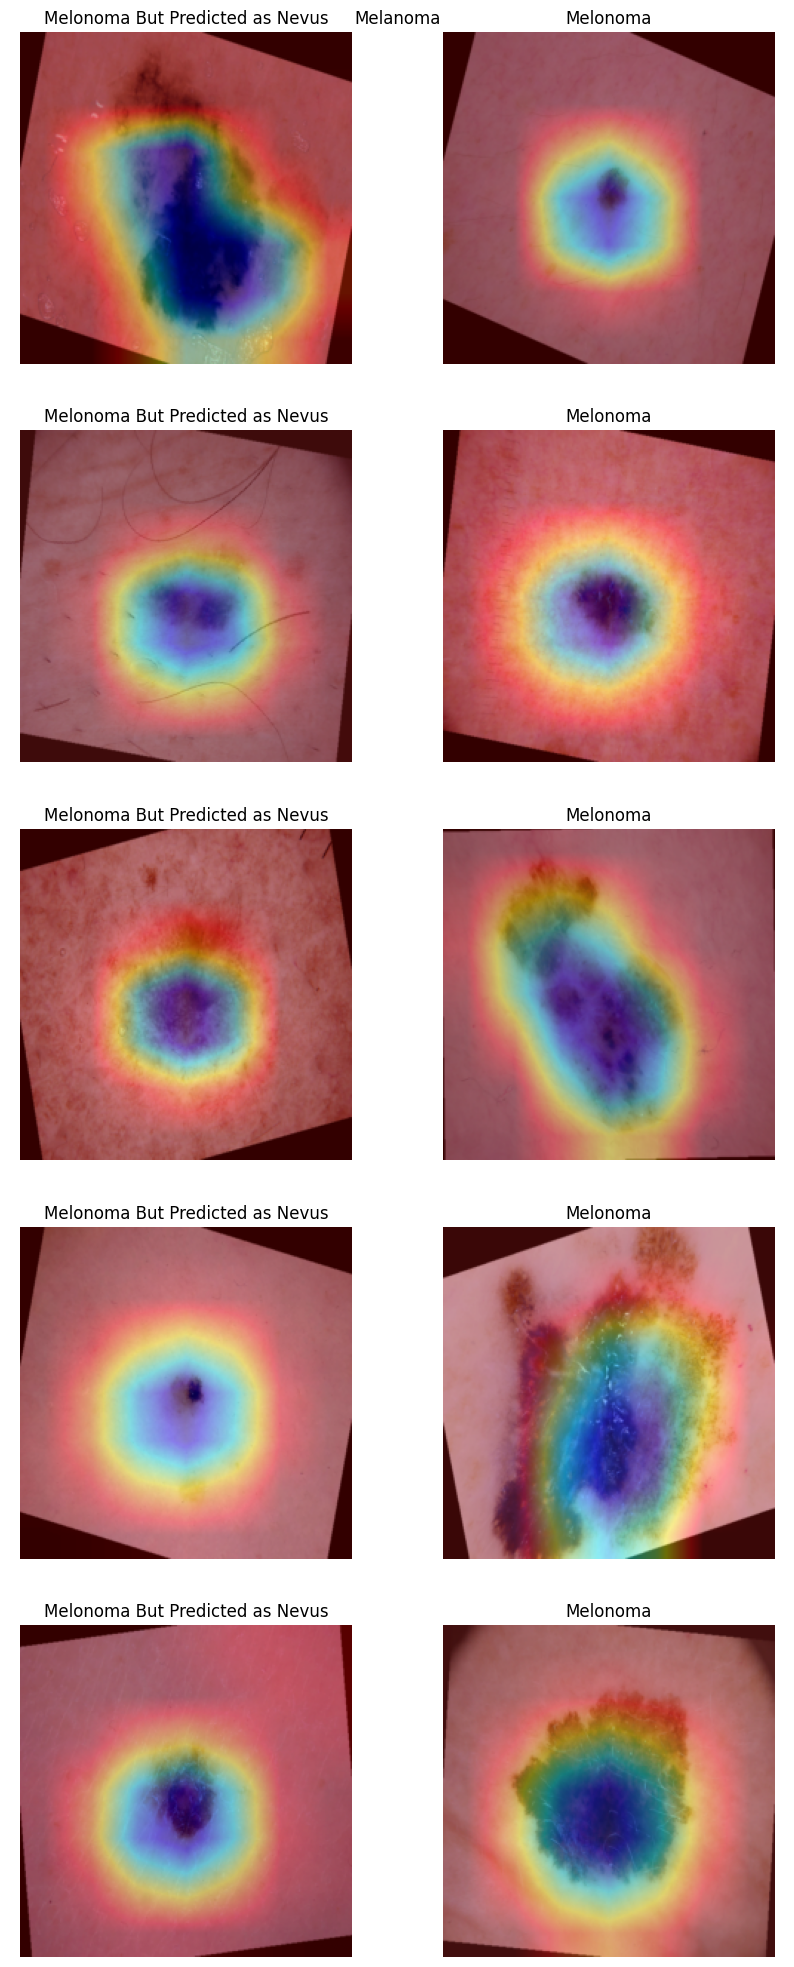

In [106]:
plt.figure(figsize=(10,5*5))
plt.title("Melanoma")
plt.axis('off')
for i in range(5): 
    plt.subplot(5,2,2*i + 1)
    grad_cam(model, train_transform(vis_images[i]))
    plt.title("Melonoma But Predicted as Nevus")

    plt.subplot(5,2,2*i + 2)
    grad_cam(model, train_transform(vis_images1[i]))
    plt.title("Melonoma")

#### This Is Very Important To Know What's Happening Here!! 
* The Model Is Working As It'Supposed To Work For This Model, Since Its A Base Model, The Model As Learned Edges, it is Focusing On Those, To Actually Train On The Model Which See's The Lesions We Need More Layers of Convalutions.
* But Why Still The Wrong Assumptions U ask Its As Mentioned Before The Early Stages Of Melanoma Looks Very Simlier To Nevu, Even For Senior Doctors Its Difficult To Identity Without Further Tests..

#### From This We Know That The Model Is Working Well, So Now We Can Move To Deployment